# Results

Grounded in the current-best config
(`dl/configs/structure_saprot_only_linear_splitpool_temp5_same_pdb_allowed_20ep.yaml`
-- SaProt structure-only embeddings, linear regression head,
`norm_softmax_by_chain_role` pooling at temperature 5.0, `same_pdb_allowed` split).

What we measure, per the three stratification axes in `docs/03_model_and_training.md`
(`dl/training/lightning_module.py`, `dl/metrics/regression_metrics.py`):

1. **Seen vs. unseen complex** -- does the model do better on new mutations of
   complexes it saw in training (`complex_seen_in_train`) than on wholly new complexes?
2. **Tail / high-magnitude performance** -- how well does it do on the largest-|ΔΔG|
   mutations, the hardest and most consequential cases?
3. **Binned error** -- MAE broken into 5 magnitude buckets, compared bucket-for-bucket
   against a naive baseline.

## Bucketed MAE vs. naive baseline

The centerpiece: for each bounded `same_pdb_allowed_val.csv` row, a naive baseline
predicts its complex's mean train ΔΔG (global mean if unseen); both model and baseline
are bucketed by the row's true ΔΔG magnitude. The model beats the baseline overall
(0.84 vs. 1.28 kcal/mol) and by the widest margin on both large-magnitude buckets --
exactly where a naive per-complex average is weakest.


,n,model_mae,baseline_mae
bucket,,,
large_destabilizing,12,1.294,3.221
moderate_destabilizing,16,0.559,2.515
near_zero,103,0.751,0.978
moderate_stabilizing,27,0.736,0.497
large_stabilizing,23,1.343,1.678
overall,181,0.843,1.280


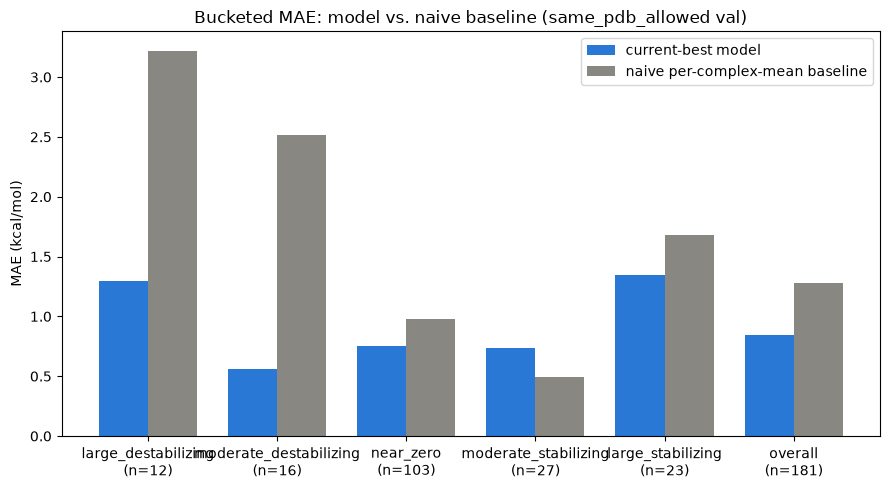

In [1]:
import os
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

os.environ.setdefault("SKEMPI_USE_SAPROT_STRUCTURE", "1")
os.environ.setdefault("SKEMPI_USE_SMALL_CHECKPOINTS", "0")

import matplotlib.pyplot as plt
from IPython.display import display

import notebooks.utils as lib

bucketed_results = lib.load_bucketed_results()
bucket_df = lib.bucketed_results_to_dataframe(bucketed_results)
display(bucket_df.round(3))

lib.plot_bucketed_mae_bar_chart(bucket_df)
plt.show()


## Classical-regressor comparison

Fit `random_forest` directly on the model's frozen (untrained-head) pooled
representation, to test whether a learned head is even necessary
(`same_pdb_allowed` split; see `docs/future_work.md`).

**`random_forest` on the untrained frozen representation (MAE 1.152 new-complex /
0.843 seen-complex) ties the trained linear head (1.052 / 0.841)** -- most of the
signal already lives upstream, in the SaProt embeddings + pooling, not in the
learned head itself.


## Caveat: train/val chain-role mix

`data/splitting.py` assigns splits by complex identity only, with no stratification
by mutated chain role. Val under-represents the harder `antigen_only` group relative
to train by ~7.6 points (26.7% vs. 34.3%), so val's aggregate MAE likely understates
the model's true error on a heavier antigen-mutation mix.


In [2]:
lib.chain_role_mix_comparison_table()


,train (n=855),val (n=202)
antigen_only,0.343,0.267
antibody_only,0.599,0.653
both,0.058,0.079
